In [1]:
# IMPORT LIBRARIES
# Think of this as gathering all your tools before starting work

import pandas as pd          # For handling data tables
import numpy as np           # For mathematical operations
import matplotlib.pyplot as plt  # For basic plotting
import seaborn as sns        # For beautiful graphs (built on matplotlib)

# This command makes graphs appear inside the notebook
%matplotlib inline

In [2]:
# LOAD THE IRIS DATASET
# Seaborn has sample datasets built-in, so we don't need to download anything

iris = sns.load_dataset('iris')

# What does this do? It downloads the famous iris dataset into a variable called 'iris'

In [3]:
# METHOD 1: Look at first few rows
print("FIRST 5 ROWS OF DATA:")
print(iris.head())

FIRST 5 ROWS OF DATA:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [4]:
# METHOD 2: Check how many rows and columns
print(f"\nDATASET SHAPE: {iris.shape}")
print(f"Rows: {iris.shape[0]}, Columns: {iris.shape[1]}")


DATASET SHAPE: (150, 5)
Rows: 150, Columns: 5


In [5]:
# METHOD 3: Check column names
print(f"\nCOLUMN NAMES: {iris.columns.tolist()}")


COLUMN NAMES: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


In [6]:
# METHOD 4: Get statistical summary
print("\nSTATISTICAL SUMMARY:")
print(iris.describe())


STATISTICAL SUMMARY:
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


In [7]:
# METHOD 5: Check for missing data
print("\nMISSING VALUES IN EACH COLUMN:")
print(iris.isnull().sum())
# All zeros = no missing data. If any number >0, we need to fix it.


MISSING VALUES IN EACH COLUMN:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [8]:
# METHOD 6: Check unique values in species column
print(f"\nUNIQUE SPECIES: {iris['species'].unique()}")
print(f"Count of each species:")
print(iris['species'].value_counts())
# You should see 50 of each species (setosa, versicolor, virginica)


UNIQUE SPECIES: <StringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str
Count of each species:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


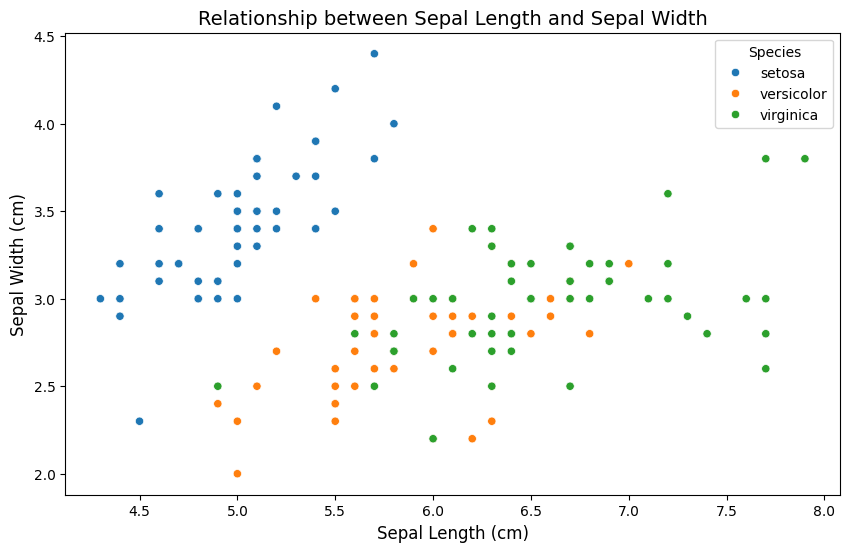

In [9]:
# SCATTER PLOT - Shows relationship between two variables

# Create a figure (canvas) with specific size
plt.figure(figsize=(10, 6))

# Create scatter plot
# x = sepal_length, y = sepal_width, color by species
sns.scatterplot(data=iris, x='sepal_length', y='sepal_width', hue='species')

# Add title and labels
plt.title('Relationship between Sepal Length and Sepal Width', fontsize=14)
plt.xlabel('Sepal Length (cm)', fontsize=12)
plt.ylabel('Sepal Width (cm)', fontsize=12)

# Add legend
plt.legend(title='Species')

# Display the graph
plt.show()

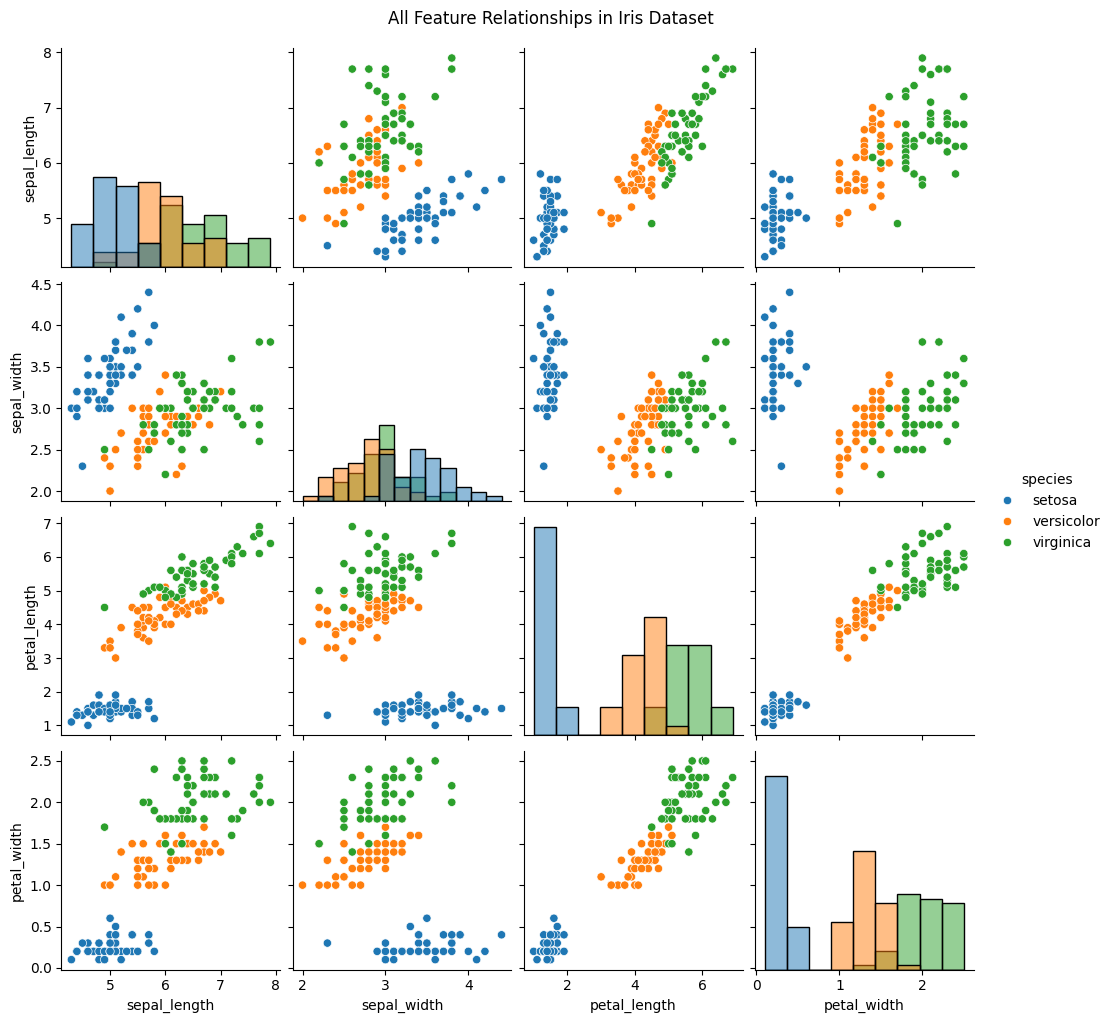

In [10]:
# Let's check ALL pairs of features with one command
# This creates multiple scatter plots at once

sns.pairplot(iris, hue='species', diag_kind='hist')
plt.suptitle('All Feature Relationships in Iris Dataset', y=1.02)
plt.show()

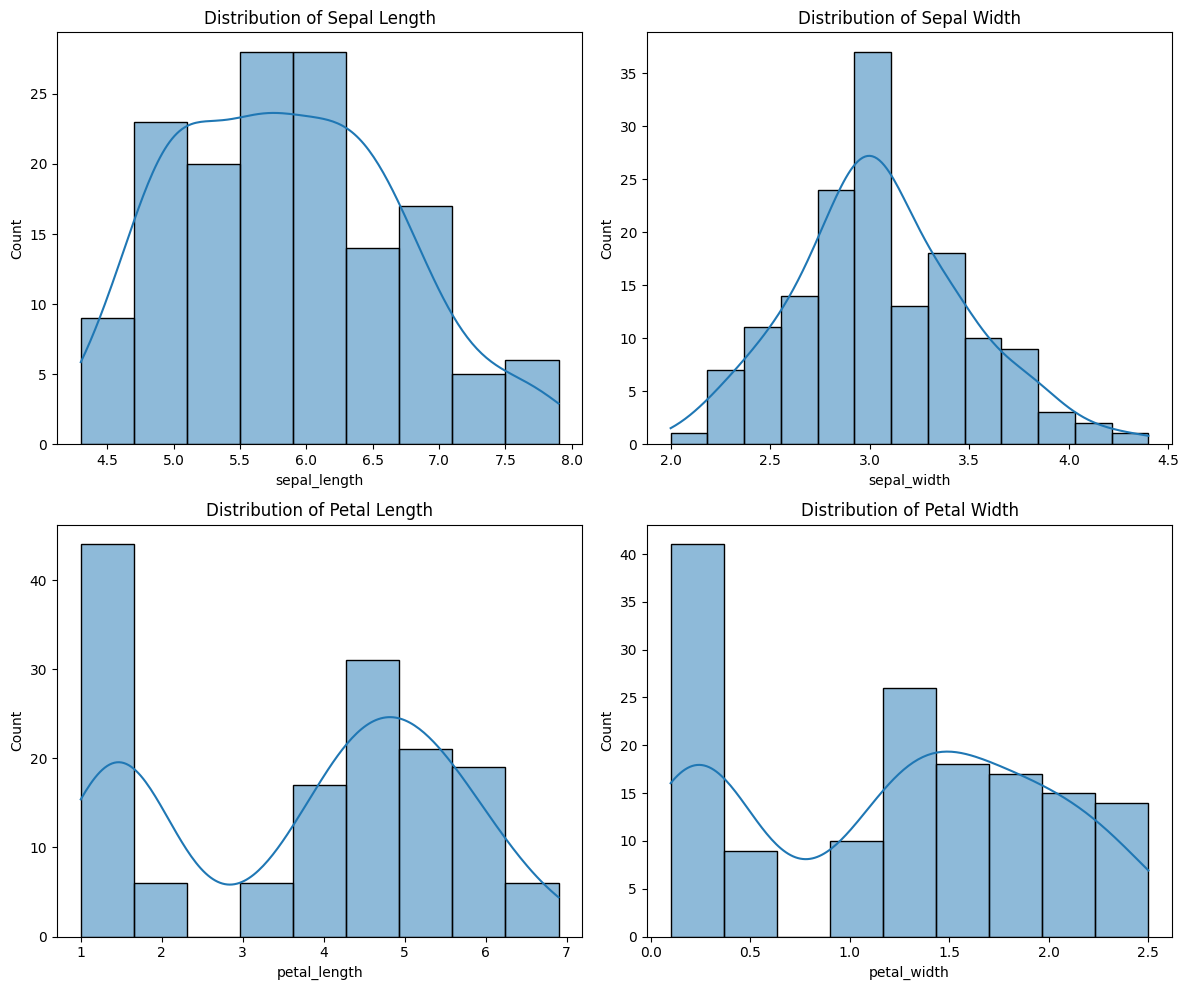

In [11]:
# HISTOGRAM - Shows how values are distributed

# Create a figure with 2 rows, 2 columns of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Distribution of sepal length
sns.histplot(data=iris, x='sepal_length', kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Sepal Length')
# kde=True adds a smooth curve over the bars

# Plot 2: Distribution of sepal width
sns.histplot(data=iris, x='sepal_width', kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Sepal Width')

# Plot 3: Distribution of petal length
sns.histplot(data=iris, x='petal_length', kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Petal Length')

# Plot 4: Distribution of petal width
sns.histplot(data=iris, x='petal_width', kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Distribution of Petal Width')

# Adjust spacing between subplots
plt.tight_layout()
plt.show()

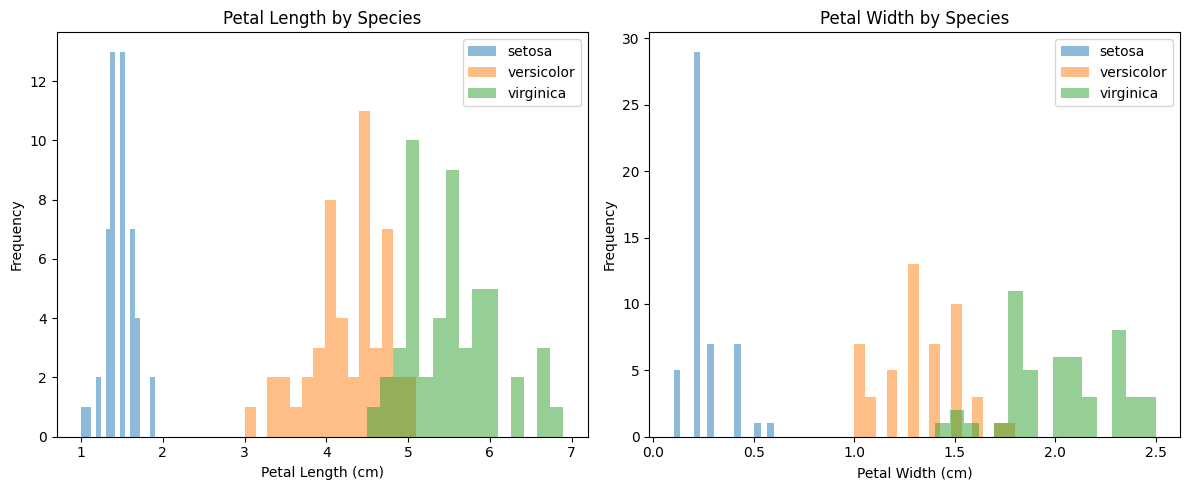

In [12]:
# Better: Show distribution by species
plt.figure(figsize=(12, 5))

# Plot 1: Petal length distribution by species
plt.subplot(1, 2, 1)  # (rows, columns, position)
for species in iris['species'].unique():
    subset = iris[iris['species'] == species]
    plt.hist(subset['petal_length'], alpha=0.5, label=species, bins=15)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Frequency')
plt.title('Petal Length by Species')
plt.legend()

# Plot 2: Petal width distribution by species
plt.subplot(1, 2, 2)
for species in iris['species'].unique():
    subset = iris[iris['species'] == species]
    plt.hist(subset['petal_width'], alpha=0.5, label=species, bins=15)
plt.xlabel('Petal Width (cm)')
plt.ylabel('Frequency')
plt.title('Petal Width by Species')
plt.legend()

plt.tight_layout()
plt.show()

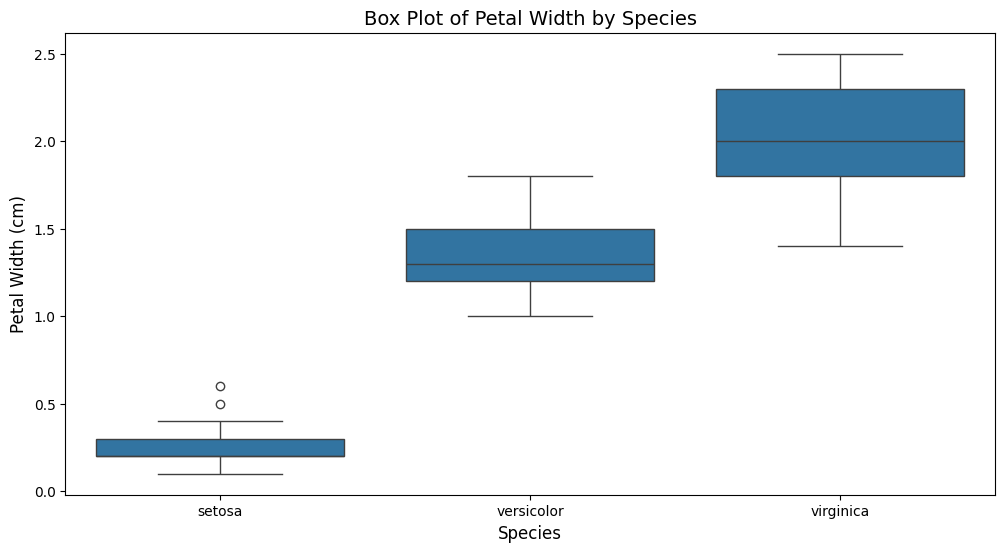

In [13]:
# BOX PLOT - Shows median, quartiles, and outliers

plt.figure(figsize=(12, 6))

# Box plot for petal width by species
sns.boxplot(data=iris, x='species', y='petal_width')

plt.title('Box Plot of Petal Width by Species', fontsize=14)
plt.xlabel('Species', fontsize=12)
plt.ylabel('Petal Width (cm)', fontsize=12)
plt.show()

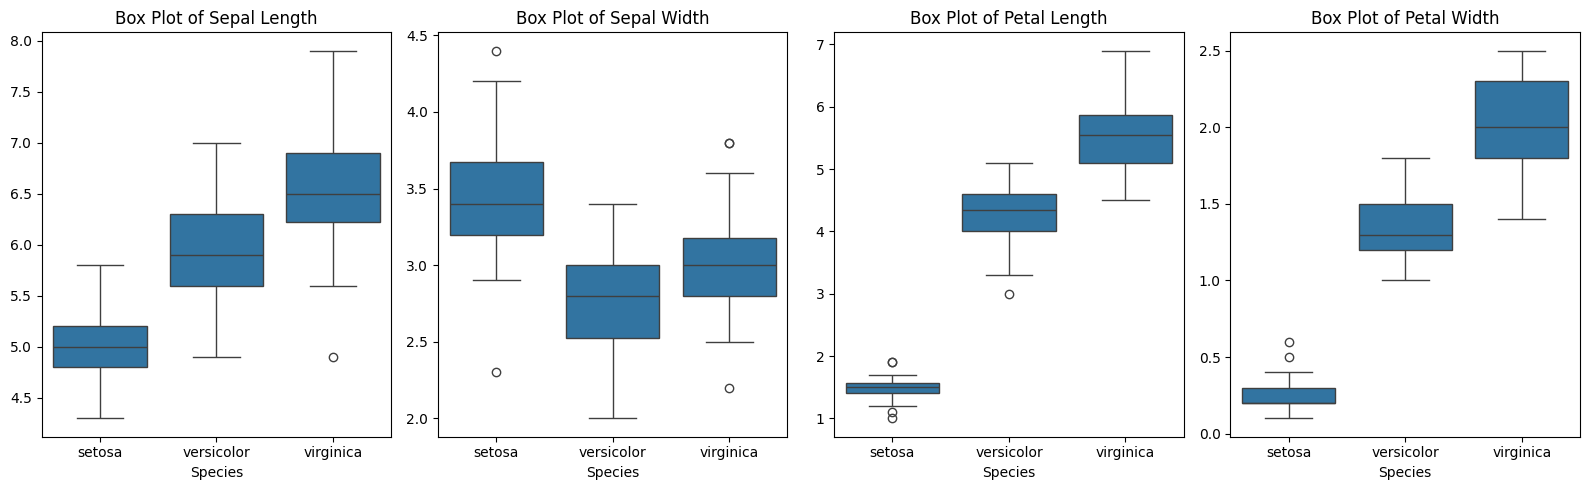

In [14]:
# Create box plots for ALL features
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for i, feature in enumerate(features):
    sns.boxplot(data=iris, x='species', y=feature, ax=axes[i])
    axes[i].set_title(f'Box Plot of {feature.replace("_", " ").title()}')
    axes[i].set_xlabel('Species')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

## Key Insights from Iris Dataset Analysis

1. **Dataset Overview**: 150 samples, 4 features, 3 species (50 each)

2. **Species Separation**:
   - Setosa is clearly separated from Versicolor and Virginica
   - Petal measurements are most effective for classification
   - Setosa has distinctively smaller petals (petal length < 2cm)

3. **No Missing Data**: Dataset is clean and ready for modeling

4. **Outliers**: Few outliers present in sepal width for all species

5. **Recommendation**: For classification tasks, petal length and petal width are the most important features.